In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from scipy.spatial import ConvexHull, QhullError
import seaborn as sns
from geopy import distance, Point
from tqdm import tqdm

# TDT4173 Project: Report
## Group [81]
### Members: Christian Lindahl Elseth, Jakob Rude Øvstaas, Aleksander Harildstad
### Kaggle Team Name: 81 - XXX


## Introduction

## Exploratory Data Analysis

This project addresses the task of predicting future positions of maritime vessels based on AIS data. The primary goal is to predict the location of 216 vessels at specific timestamps up to five days into the future.

The initial phase of the project involved data pre-processing and exploratory data analysis to clean and understand the dataset. Using the training data, we engineered features that we believed would best capture vessel dynamics and movement trends. Key features included last_latitude, last_longitude, last_sog (speed over ground), and delta_time. We also decomposed directional features, such as sin_last_heading and cos_last_heading, to provide continuous representations of vessel headings.

Initially, our model achieved a Kaggle score of around 140. To improve this, we experimented with multiple machine learning algorithms, including XGBoost and Random Forest. We found that the Random Forest algorithm consistently provided the most stable results for this task, though it did not significantly improve our score.

After consulting with other project teams, we introduced a sliding window approach to further enhance the model. By including the last known values within a five-day window, we allowed the model to capture recent trends in vessel movement. This approach involved initializing the window with the vessel’s last known positions, then updating key attributes like last_latitude, last_longitude, and last_sog based on the most recent data within each window. The sliding window methodology provided the model with better context from recent days, leading to more accurate predictions and reducing our score to 96.

To ensure model interpretability, we analyzed feature importance to identify which attributes had the greatest influence on our predictions, (Hva fant vi ut her??)

Two Jupyter notebooks are attached to this report, representing two Kaggle submissions with scores of 140 and 96, respectively. These notebooks demonstrate the evolution of our model’s performance as we integrated the sliding window technique.

In [2]:
# First we import the necessary CSV files. NOTE: Different delimiter for some files.
df_train = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ais_train.csv', delimiter = '|')
df_test = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ais_test.csv')
df_vessels = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/vessels.csv', delimiter = '|')
df_schedules = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/schedules_to_may_2024.csv', delimiter = '|')
df_ports = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ports.csv', delimiter = '|')

A common cause of errors in machine learning is the existence of NaN values, as they can interfere with model training and evaluation. Some models handle NaN values by default, but at we will experiment with different models it is important that we consider this. 

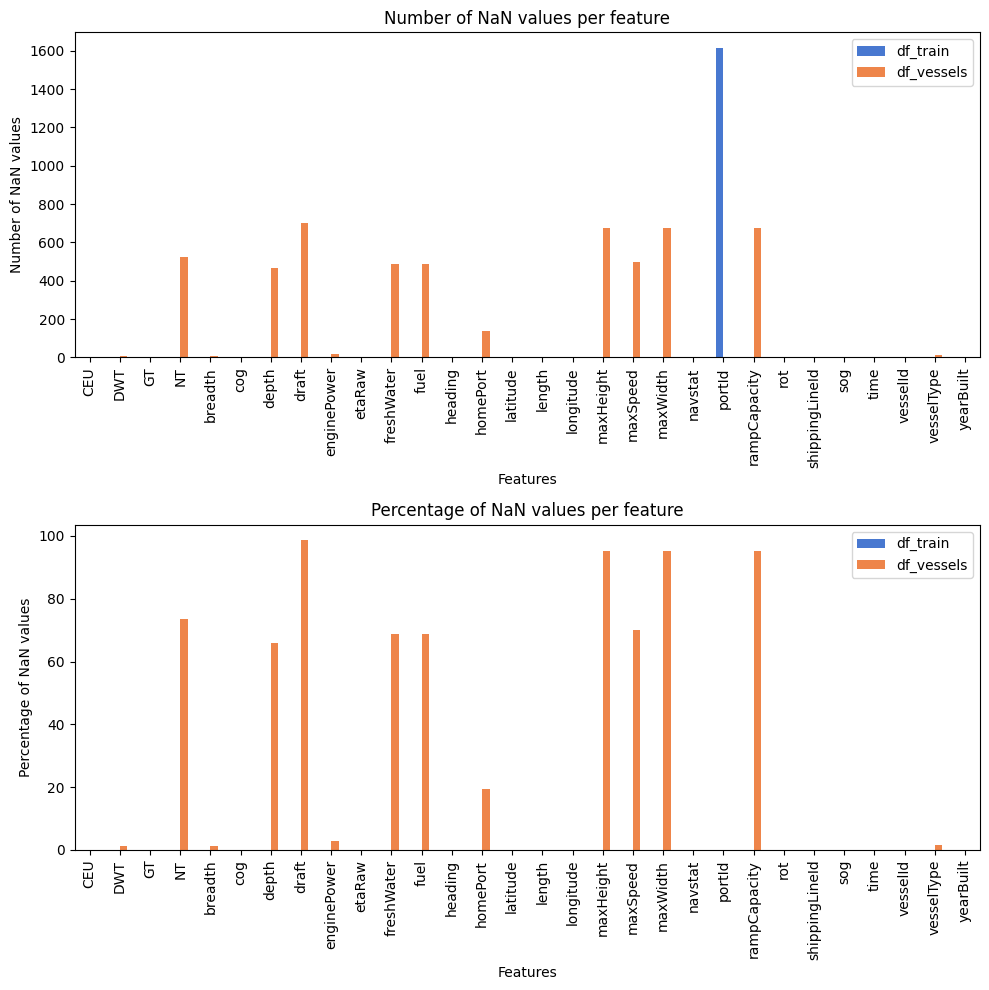

In [3]:
nan_counts = pd.DataFrame({
    'df_train': df_train.isna().sum(),
    'df_vessels': df_vessels.isna().sum()
})

total_counts = pd.Series({
    'df_train': df_train.shape[0],
    'df_vessels': df_vessels.shape[0]
})

nan_percentage = (nan_counts.divide(total_counts, axis=1)) * 100
nan_counts = nan_counts[['df_train', 'df_vessels']]
nan_percentage = nan_percentage[['df_train', 'df_vessels']]

palette = sns.color_palette("muted")
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

nan_counts.plot(kind='bar', color=palette, ax=axes[0])
axes[0].set_title('Number of NaN values per feature')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Number of NaN values')
axes[0].tick_params(axis='x', rotation=90)

nan_percentage.plot(kind='bar', color=palette, ax=axes[1])
axes[1].set_title('Percentage of NaN values per feature')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Percentage of NaN values')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

As we can see from the plot above, several of the features in the vessel data consist of well above 60% NaN values. Which is a strong indicator towards choosing not to use these features for future analysis. To check for other abnormalities in the data, we can check for outliers below.

In [4]:
df_train.describe()

,cog,sog,rot,heading,navstat,latitude,longitude
count,1.522065e+06,1.522065e+06,1.522065e+06,1.522065e+06,1.522065e+06,1.522065e+06,1.522065e+06
mean,1.782494e+02,6.331703e+00,5.054561e-01,1.762737e+02,2.092604e+00,3.658497e+01,1.153646e+01
std,1.076785e+02,7.539364e+00,1.760916e+01,1.070860e+02,2.411965e+00,2.290488e+01,6.871572e+01
min,0.000000e+00,0.000000e+00,-1.270000e+02,0.000000e+00,0.000000e+00,-4.753287e+01,-1.675409e+02
25%,7.820000e+01,0.000000e+00,0.000000e+00,7.500000e+01,0.000000e+00,3.451683e+01,-5.212810e+00
50%,1.838000e+02,5.000000e-01,0.000000e+00,1.800000e+02,0.000000e+00,4.223370e+01,4.234350e+00
75%,2.690000e+02,1.410000e+01,0.000000e+00,2.650000e+02,5.000000e+00,5.135197e+01,1.883715e+01
max,3.600000e+02,1.023000e+02,1.280000e+02,5.110000e+02,1.500000e+01,7.055720e+01,1.788054e+02


In [5]:
df_vessels.describe()

,CEU,DWT,GT,NT,vesselType,breadth,depth,draft,enginePower,freshWater,fuel,length,maxHeight,maxSpeed,maxWidth,rampCapacity,yearBuilt
count,711.000000,703.000000,711.000000,187.000000,699.000000,703.000000,242.000000,10.000000,691.000000,221.000000,221.000000,711.000000,35.000000,213.000000,35.000000,34.000000,711.000000
mean,5006.454290,18556.291607,51207.534459,17931.326203,72.424893,31.102703,21.383140,9.750000,6789.522431,484.764932,2985.804525,195.176661,5.165714,21.695775,12.834286,164.705882,2007.455696
std,2186.256335,8562.952922,16329.899399,3838.264571,23.366361,3.563432,2.658188,3.229355,7342.526020,136.657132,427.018341,23.789823,0.604854,0.797420,5.232193,80.781610,6.067734
min,0.000000,3222.000000,8659.000000,3137.000000,14.000000,18.000000,11.900000,5.750000,0.000000,178.850000,502.000000,99.900000,3.000000,16.700000,0.000000,80.000000,1985.000000
25%,3800.000000,14267.000000,39362.000000,15576.000000,83.000000,31.000000,21.120000,7.640000,0.000000,369.000000,2808.000000,183.000000,5.000000,21.400000,11.300000,127.500000,2004.000000
50%,5400.000000,18720.000000,56738.000000,18474.000000,83.000000,32.000000,21.310000,9.185000,0.000000,471.000000,2991.000000,199.000000,5.000000,21.800000,15.200000,150.000000,2008.000000
75%,6500.000000,21281.000000,60619.500000,19152.000000,83.000000,32.260000,22.040000,9.932500,14121.000000,567.000000,3185.000000,199.990000,5.100000,22.200000,15.200000,150.000000,2011.000000
max,8500.000000,108650.000000,100430.000000,29329.000000,83.000000,42.000000,32.600000,15.400000,36000.000000,806.580000,4454.000000,296.000000,6.500000,23.300000,19.300000,375.000000,2022.000000


Observing speed over ground (SOG) from the train set we can see that the maximum value is 102.3 knots. Which is documented in the project description. To avoid this affecting the data, we can set a upper limit of 30 knots to disregard erranous features. Simultanouesly, we can set limits for rotational features, as we know these should not exceed 360 degrees.

In [6]:
# Calculate means of the columns without outliers
sog_mean = df_train.loc[df_train['sog'] < 30, 'sog'].mean()
cog_mean = df_train.loc[df_train['cog'] < 360, 'cog'].mean()
heading_mean = df_train.loc[df_train['heading'] < 360, 'heading'].mean()

# Cleaning the data. Ensuring all data is within reasonable limits and replacing outliers/erranous data with NaN
df_train['cog'] = df_train['cog'].apply(lambda x: float(x) if float(x) < 360 else cog_mean)
# NOTE: We determine that SOG above 25 knots shall be disregarded.
df_train['sog'] = df_train['sog'].apply(lambda x: float(x) if float(x) < 50 else sog_mean)
df_train['heading'] = df_train['heading'].apply(lambda x: float(x) if float(x) < 360 else heading_mean)
# NOTE: Navstat of 0 and 8 both indicate a moving vessel. We therefore combine these two

At this point, we can already see that there is some overlapping features in the different datasets. A full overview of overlapping and unique features can be seen below.

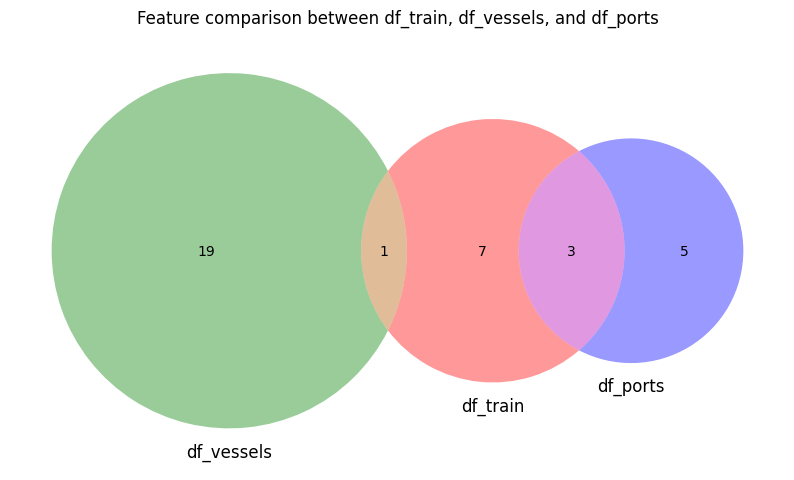


Features common to df_train and df_vessels:
{'vesselId'}

Features common to df_train and df_ports:
{'latitude', 'longitude', 'portId'}


In [7]:
train_features = set(df_train.columns)
vessel_features = set(df_vessels.columns)
port_features = set(df_ports.columns)

common_train_vessel_port = train_features & vessel_features & port_features
common_train_vessel = train_features & vessel_features
common_train_port = train_features & port_features

plt.figure(figsize=(10, 8))
venn3([train_features, vessel_features, port_features], ('df_train', 'df_vessels', 'df_ports'))
plt.title('Feature comparison between df_train, df_vessels, and df_ports')
plt.show()

print("\nFeatures common to df_train and df_vessels:")
print(common_train_vessel)
print("\nFeatures common to df_train and df_ports:")
print(common_train_port)

Based on the venn diagram, we can merge desired features based on vessel and port ID. Based on the NaN analysis completed earlier, we select four features to be merged into the training and test set. Specifically, these are:
- Gross tonnage (GT)
- Length
- Port latitude
- Port longitude

In [8]:
# Renaming port data and then merging with df_train
df_ports = df_ports.rename(columns = {'latitude': 'port_lat', 'longitude': 'port_long'})
df_train = df_train.merge(df_ports[['portId', 'port_lat', 'port_long']], on = 'portId', how = 'left')

# Merging some vessel specific data
df_train = df_train.merge(df_vessels[['vesselId', 'length', 'GT']], on = 'vesselId', how = 'left')
df_test = df_test.merge(df_vessels[['vesselId', 'length', 'GT']], on = 'vesselId', how = 'left')

Moving on, we will go further into finding possible outliers.

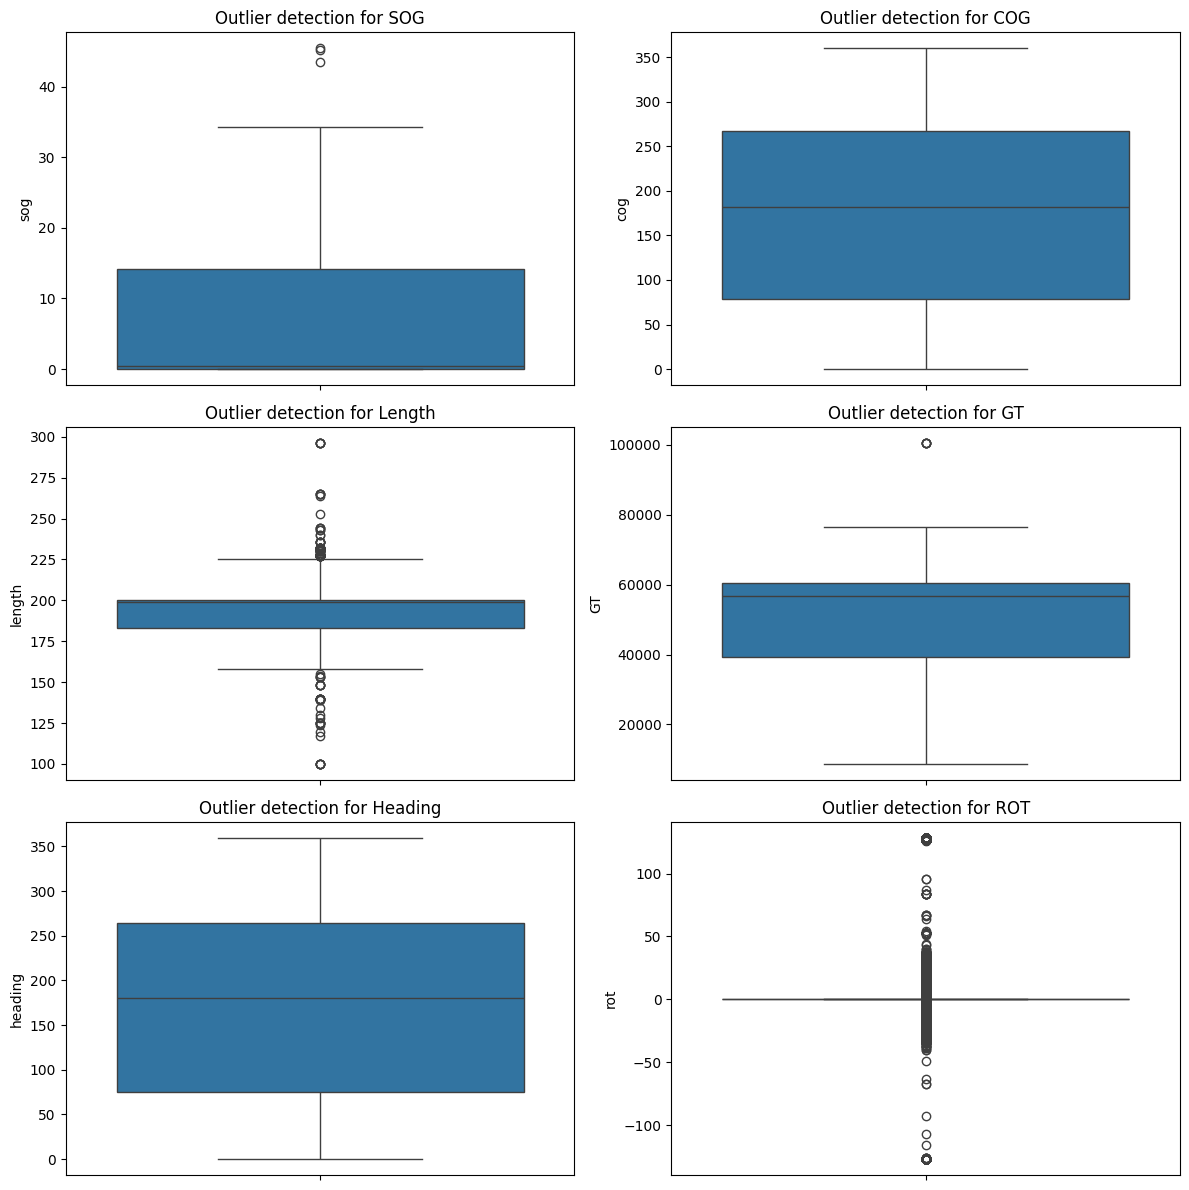

Highest value for SOG: 45.4
Highest value for COG: 359.9
Highest value for Length: 296.0
Highest value for GT: 100430
Highest value for Heading: 359.0
Highest value for ROT: 128


In [9]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

sns.boxplot(y=df_train['sog'], ax=axes[0, 0])
axes[0, 0].set_title("Outlier detection for SOG")

sns.boxplot(y=df_train['cog'], ax=axes[0, 1])
axes[0, 1].set_title("Outlier detection for COG")

sns.boxplot(y=df_vessels['length'], ax=axes[1, 0])
axes[1, 0].set_title("Outlier detection for Length")

sns.boxplot(y=df_vessels['GT'], ax=axes[1, 1])
axes[1, 1].set_title("Outlier detection for GT")

sns.boxplot(y=df_train['heading'], ax=axes[2, 0])
axes[2, 0].set_title("Outlier detection for Heading")

sns.boxplot(y=df_train['rot'], ax=axes[2, 1])
axes[2, 1].set_title("Outlier detection for ROT")

plt.tight_layout()
plt.show()

print("Highest value for SOG:", df_train['sog'].max())
print("Highest value for COG:", df_train['cog'].max())
print("Highest value for Length:", df_vessels['length'].max())
print("Highest value for GT:", df_vessels['GT'].max())
print("Highest value for Heading:", df_train['heading'].max())
print("Highest value for ROT:", df_train['rot'].max())

Starting with the outlier plot for length, we can see that there are some lengths that lie well outside the interquartile range. We choose to keep these values, as a length of < 300 meters is normal. Looking at the gross tonnage, there is a value of 100 4300 tonnes which is well above the rest. Although this value is much higher, we keep it as some vessels (oil tankers, container ships) [can be well above 150 000 tonnes.](https://maersktankers.com/ships)

Further, by visualizing the distribution of selected features we can get a better understanding of the data structure and bias.

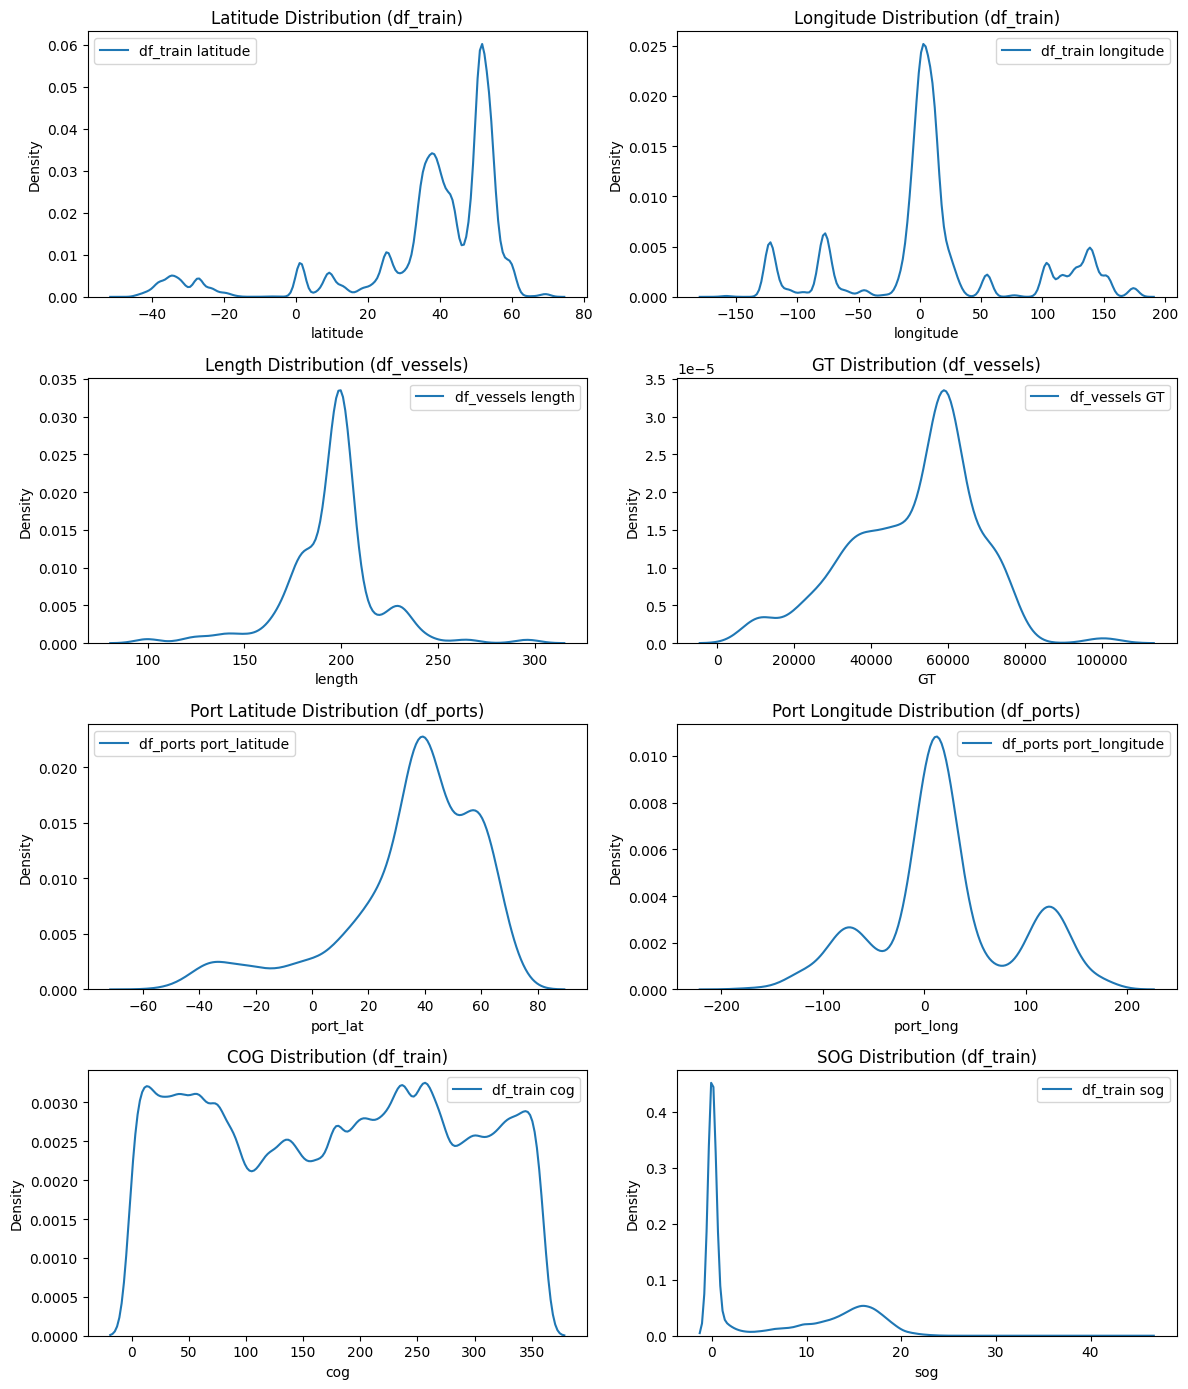

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))

sns.kdeplot(df_train['latitude'], ax=axes[0, 0], label='df_train latitude')
axes[0, 0].set_title('Latitude Distribution (df_train)')
axes[0, 0].legend()

sns.kdeplot(df_train['longitude'], ax=axes[0, 1], label='df_train longitude')
axes[0, 1].set_title('Longitude Distribution (df_train)')
axes[0, 1].legend()

sns.kdeplot(df_vessels['length'], ax=axes[1, 0], label='df_vessels length')
axes[1, 0].set_title('Length Distribution (df_vessels)')
axes[1, 0].legend()

sns.kdeplot(df_vessels['GT'], ax=axes[1, 1], label='df_vessels GT')
axes[1, 1].set_title('GT Distribution (df_vessels)')
axes[1, 1].legend()

sns.kdeplot(df_ports['port_lat'], ax=axes[2, 0], label='df_ports port_latitude')
axes[2, 0].set_title('Port Latitude Distribution (df_ports)')
axes[2, 0].legend()

sns.kdeplot(df_ports['port_long'], ax=axes[2, 1], label='df_ports port_longitude')
axes[2, 1].set_title('Port Longitude Distribution (df_ports)')
axes[2, 1].legend()

sns.kdeplot(df_train['cog'], ax=axes[3, 0], label='df_train cog')
axes[3, 0].set_title('COG Distribution (df_train)')
axes[3, 0].legend()

sns.kdeplot(df_train['sog'], ax=axes[3, 1], label='df_train sog')
axes[3, 1].set_title('SOG Distribution (df_train)')
axes[3, 1].legend()

plt.tight_layout()
plt.show()

## Supplementary Functions

In [ ]:
# Function for Kaggle submission
def submit(test_ids, ylong, ylat):
    submission = pd.DataFrame({
        'ID': test_ids,  # Pass the test ID column
        'longitude_predicted': ylong,  # Your predicted longitudes
        'latitude_predicted': ylat    # Your predicted latitudes
    })

    submission = submission[['ID', 'longitude_predicted', 'latitude_predicted']].sort_values(by = 'ID').reset_index(drop=True)

    i = 1
    while os.path.exists(f'submission_{i}.csv'): # This ensures no file is overwritten
        i += 1

    filename = f'submission_{i}.csv'
    submission.to_csv(filename, index=False)
    print(f"Results saved to {filename}")

# Function for calcualting the convex hull area for each vessel
def calculate_convex_hull_area(df):
    results = []
    
    # Grouping by vessel data and then iterating through all vessels
    for vessel_id, vessel_data in df.groupby('vesselId'):
        # Ensuring at least three unique points exist.
        unique_points = vessel_data[['latitude', 'longitude']].drop_duplicates()
        if len(unique_points) < 3:
            results.append({'vesselId': vessel_id, 'covered_area': 0})
            continue

        lat_to_m = 111320  # meters per degree latitude
        long_to_m = 40075000 * np.cos(np.radians(vessel_data['latitude'].mean())) / 360  # meters per degree longitude
        
        # Creating points for ConvexHull conversion
        points = np.column_stack((unique_points['longitude'] * long_to_m, unique_points['latitude'] * lat_to_m))
        
        # Calculating the convex hull area. NOTE: if ConvexHull fails; area is set to 0
        try:
            hull = ConvexHull(points)
            area = hull.area
        except QhullError:
            area = 0

        results.append({'vesselId': vessel_id, 'covered_area': area})
    
    return pd.DataFrame(results)

# Function for calculating the haversine distance between two points
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000 # Mean Earth radius in meters
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1) # Degrees --> radians
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2) # Degrees --> radians

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

# Function for calculating the average deviation in position
def average_distance_in_meters(y_true_lat, y_true_long, y_pred_lat, y_pred_long):
    distances = haversine_distance(y_true_lat, y_true_long, y_pred_lat, y_pred_long)
    avg_distance = np.mean(distances)
    return avg_distance

# Function for calculating the estimated target position based on historical data
def estimate_position(lat, long, cog, sog, time_diff):
    cog_rad = np.deg2rad(cog)
    distance_m = sog * 0.514444 * time_diff
    origin = Point(lat, long)
    target = distance.distance(meters = distance_m).desination(origin, cog_rad)
    target_lat, target_long = target.latitude, target.longitude
    return target_lat, target_long

# Function for calculated an estimated position based on historical data
def estimate_position(lat, long, cog, sog, time_diff):
    cog_rad = np.deg2rad(cog)
    distance_m = sog * 0.514444 * time_diff
    origin = Point(lat, long)
    target = distance.distance(meters = distance_m).desination(origin, cog_rad)
    target_lat, target_long = target.latitude, target.longitude
    return target_lat, target_long

# Function for calculating the change in position
def delta_position(row):
    earth_radius = 6371000 # Mean Earth radius in meters
    cog_rad = np.deg2rad(row['last_cog']) # Degrees --> radians
    estimated_delta_lat = (row['estimated_distance'] * np.cos(cog_rad)) / earth_radius
    estimated_delta_long = (row['estimated_distance'] * np.sin(cog_rad)) / (earth_radius * np.cos(np.deg2rad(row['last_lat'])))
    
    return np.rad2deg(estimated_delta_lat), np.rad2deg(estimated_delta_long)

# Function for creating the first window
def initial_window(row):
    row['last_lat'] = row['latitude']
    row['last_long'] = row['longitude']
    row['last_sog'] = row['sog']
    row['last_cog'] = row['cog']
    row['last_heading'] = row['heading']
    row['last_is_moving'] = row['is_moving']
    # NOTE: the three below features are set to 0 for the first window only.
    row['time_diff'] = 0
    row['estimated_distance'] = 0
    row['estimated_delta_lat'] = 0
    row['estimated_delta_long'] = 0
    
    return row

# Function for retrieving the last known values
def get_last_known_values(train_df):
    # Sort data by 'vesselId' and 'time' to ensure chronological order
    train_df = train_df.sort_values(by=['vesselId', 'time']).reset_index(drop=True)

    # Get the last known values for each vessel
    last_known_values = train_df.groupby('vesselId').last().reset_index()

    # Select only the relevant columns to carry forward to the test set
    columns_to_keep = ['vesselId', 'latitude', 'longitude', 'port_lat', 'port_long', 
                       'cog', 'sog', 'heading', 'is_moving', 'time']
    last_known_values = last_known_values[columns_to_keep]

    return last_known_values

## Feature Engineering

In [ ]:
# Train and test is sorted by vessel ID and time. Time is converted to datetime
df_train = df_train.sort_values(by = ['vesselId', 'time'])
df_test = df_test.sort_values(by = ['vesselId', 'time'])
df_train['time'] = pd.to_datetime(df_train['time'])
df_test['time'] = pd.to_datetime(df_test['time'])

# Filling NaNs with backward fill
df_train['portId'] = df_train['portId'].transform(lambda x: x.bfill())

# Using navstat to determine if vessel is moving or not
df_train['is_moving'] = df_train['navstat'].apply(lambda navstat: 1 if navstat == 0 or navstat == 8 else 0)

# Encoding vessel ID
label_encoder = LabelEncoder()
df_train['vesselId_encoded'] = label_encoder.fit_transform(df_train['vesselId'])
df_test['vesselId_encoded'] = label_encoder.transform(df_test['vesselId'])

In [ ]:
# Feature engineering for train set
def create_train(df, windowSize):
    # NOTE: this function requires df to be sorted by vessel ID and time.
    # Initializing an empty array for the data
    data = []
    # Finding all unique vessels
    vessels = df['vesselId'].unique()

    # Using tqdm for progress bar (for-loop can run slow on large dataset)
    for vessel in tqdm(vessels):
        # Finding all data for one unique vessel
        vessel_data = df[df['vesselId'] == vessel].sort_values(by='time')
        # Calculating the ConvexHull area for each vessel
        area_df = calculate_convex_hull_area(vessel_data)
        if not area_df.empty and 'covered_area' in area_df.columns:
            total_area = calculate_convex_hull_area(vessel_data)['covered_area'].values[0]
        else:
             total_area = 0
        # Initializing empty array for the internal data and the last row
        data_internal = [] 
        last_row = None
        i = 0

        while not vessel_data.empty:
            first_window_time = vessel_data['time'].min() # Initial time within window
            end_window_date = (first_window_time + pd.Timedelta(days = windowSize)).replace(hour = 23, minute = 59, second = 59)
            # Gathering the data within the specified window size
            window_rows = vessel_data[(vessel_data['time'] >= first_window_time) & (vessel_data['time'] <= end_window_date)].copy()

            if i == 0 and last_row is None: # This sets the first window
                window_rows = initial_window(window_rows)
            else: # This applies to all consecutive windows after initial window
                    window_rows['last_lat'] = last_row['latitude']
                    window_rows['last_long'] = last_row['longitude']
                    window_rows['last_port_lat'] = last_row['port_lat']
                    window_rows['last_port_long'] = last_row['port_long']
                    window_rows['last_sog'] = last_row['sog']
                    window_rows['last_cog'] = last_row['cog']
                    window_rows['last_heading'] = last_row['heading']
                    window_rows['last_is_moving'] = last_row['is_moving']
                    window_rows['time_diff'] = (window_rows['time'] - last_row['time']).dt.total_seconds()
                    window_rows['estimated_distance'] = window_rows['last_sog'] * window_rows['time_diff'] # in meters
                    deltas = window_rows.apply(lambda row: delta_position(row), axis = 1)
                    window_rows['estimated_delta_lat'], window_rows['estimated_delta_long'] = zip(*deltas)
            
            # Adding encoded vessel ID
            window_rows['vesselId_encoded'] = window_rows['vesselId_encoded']
            # Adding vessel specific data
            window_rows['length'] = window_rows['length']
            window_rows['GT'] = window_rows['GT']
            # Adding some trigonometric features
            window_rows['last_heading_sin'] = np.sin(np.deg2rad(window_rows['last_heading']))
            window_rows['last_heading_cos'] = np.cos(np.deg2rad(window_rows['last_heading']))
            # Adding horizontal and vertical expected displacement
            #window_rows['displacement_hor'] = window_rows['last_sog'] * window_rows['last_cog_cos']
            #window_rows['displacement_vert'] = window_rows['last_sog'] * window_rows['last_cog_sin']
            # Adding total ConvexHull area
            window_rows['total_area'] = total_area

            # Adding data and updating last_row
            last_row = window_rows.iloc[-1]
            data_internal.append(window_rows)
            vessel_data = vessel_data.drop(window_rows.index)
            i += 1
        
        vessel_df = pd.concat(data_internal, ignore_index = True)
        data.append(vessel_df)
    
    return pd.concat(data, ignore_index = True)

In [ ]:
train_data = create_train(df_train, 5)

In [ ]:
train_data.columns

In [ ]:
# Retrieving the last known values from train set
last_known_train_values = get_last_known_values(df_train)

In [ ]:
# Feature engineering for test set
def create_test(df, lastKnown):
    data = []
    vessels = df['vesselId'].unique()

    last_known_values_dict = lastKnown.set_index('vesselId').to_dict('index')

    for vessel in tqdm(vessels):
        vessel_data = df[df['vesselId'] == vessel].sort_values(by = 'time').reset_index(drop = True)

        if vessel in last_known_values_dict:
            last_known_values = last_known_values_dict[vessel]
        else:
            continue

        vessel_data['last_lat'] = last_known_values['latitude']
        vessel_data['last_long'] = last_known_values['longitude']
        vessel_data['last_port_lat'] = last_known_values['port_lat']
        vessel_data['last_port_long'] = last_known_values['port_long']
        vessel_data['last_cog'] = last_known_values['cog']
        vessel_data['last_heading'] = last_known_values['heading']
        vessel_data['last_sog'] = last_known_values['sog']
        vessel_data['last_is_moving'] = last_known_values['is_moving']
        
        vessel_data['time_diff'] = (vessel_data['time'] - last_known_values['time']).dt.total_seconds()
        vessel_data['estimated_distance'] = vessel_data['last_sog'] * vessel_data['time_diff']

        deltas = vessel_data.apply(lambda row: delta_position(row), axis = 1)
        vessel_data['estimated_delta_lat'], vessel_data['estimated_delta_long'] = zip(*deltas)

        vessel_data['vesselId_encoded'] = vessel_data['vesselId_encoded']

        vessel_data['length'] = vessel_data['length']
        vessel_data['GT'] = vessel_data['GT']

        vessel_data['last_heading_sin'] = np.sin(np.deg2rad(vessel_data['last_heading']))
        vessel_data['last_heading_cos'] = np.cos(np.deg2rad(vessel_data['last_heading']))

        #vessel_data['displacement_hor'] = vessel_data['last_sog'] * vessel_data['last_cog_cos']
        #vessel_data['displacement_vert'] = vessel_data['last_sog'] * vessel_data['last_cog_sin']

        data.append(vessel_data)
    
    return pd.concat(data, ignore_index = True)

In [ ]:
test_data = create_test(df_test, last_known_train_values)

In [ ]:
test_data.columns

## Model Selection

Her må vi skrive noe fornuftig om hvilke modeller vi har valgt og hvorfor (implementer GridSearch, nevn AutoML....)

## Model Interpretation

Her må vi skrive noe annet fornuftig om hvordan vi har evaluert de ulike modellene. (Få med at vi har brukt feature importance, r2 score, mae, average_distance osv osv osv...)

In [ ]:
features = [
       'last_lat', 'last_long', 'last_port_lat',
       'last_port_long', 'last_sog',
       'time_diff', 'estimated_delta_lat', 'estimated_delta_long', 
       'last_heading_sin', 'last_heading_cos']

predictors = ['latitude', 'longitude']

train_df, val_df = train_test_split(train_data, test_size = 0.2, random_state = 42)
X_train = train_df[features]
X_val = val_df[features]

y_train = train_df[predictors]
y_val_lat = val_df['latitude']
y_val_long = val_df['longitude']

RFR = RandomForestRegressor(n_estimators = 10, n_jobs = -1, random_state = 42, verbose = 2)

multi_output_regressor = MultiOutputRegressor(RFR)

multi_output_regressor.fit(X_train, y_train)

y_pred = multi_output_regressor.predict(X_val)

y_pred_lat = y_pred[:, 0]
y_pred_long = y_pred[:, 1]

# Extract feature importances for each target
latitude_importances = multi_output_regressor.estimators_[0].feature_importances_
longitude_importances = multi_output_regressor.estimators_[1].feature_importances_

# Average feature importances across targets for a combined importance
average_importances = np.mean([latitude_importances, longitude_importances], axis=0)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, average_importances, color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Average Feature Importance for Latitude and Longitude Prediction")
plt.show()

mae_lat = mean_absolute_error(y_val_lat, y_pred_lat)
mae_long = mean_absolute_error(y_val_long, y_pred_long)
r2_lat = r2_score(y_val_lat, y_pred_lat)
r2_long = r2_score(y_val_long, y_pred_long)
# Calculate the average distance in meters between predicted and actual positions in the validation set
average_distance = average_distance_in_meters(y_val_lat, y_val_long, y_pred_lat, y_pred_long)

print(f'Latitude: MAE: {mae_lat:.2f}, R^2: {r2_lat:.2f}')
print(f'Longitude: MAE: {mae_long:.2f}, R^2: {r2_long:.2f}')

print(f'Average deviation: {average_distance:.2f} meters')

In [ ]:
features = [
       'last_lat', 'last_long', 'last_port_lat',
       'last_port_long', 'last_sog',
       'time_diff', 'estimated_delta_lat', 'estimated_delta_long', 
       'last_heading_sin', 'last_heading_cos']

predictors = ['latitude', 'longitude']

X_train = train_data[features]
y_train = train_data[predictors]
X_test = test_data[features]

RFR = RandomForestRegressor(n_estimators = 100, n_jobs = -1, random_state = 42, verbose = 2)
multi_output_regressor = MultiOutputRegressor(RFR)

multi_output_regressor.fit(X_train, y_train)

y_pred = multi_output_regressor.predict(X_test)

y_pred_lat = y_pred[:, 0]
y_pred_long = y_pred[:, 1]

# Extract feature importances for each target
latitude_importances = multi_output_regressor.estimators_[0].feature_importances_
longitude_importances = multi_output_regressor.estimators_[1].feature_importances_

# Average feature importances across targets for a combined importance
average_importances = np.mean([latitude_importances, longitude_importances], axis=0)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, average_importances, color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Average Feature Importance for Latitude and Longitude Prediction")
plt.show()

submit(df_test['ID'], y_pred_long, y_pred_lat)

In [ ]:
print(pd.Series(y_pred_long).describe())
print(pd.Series(y_pred_lat).describe())